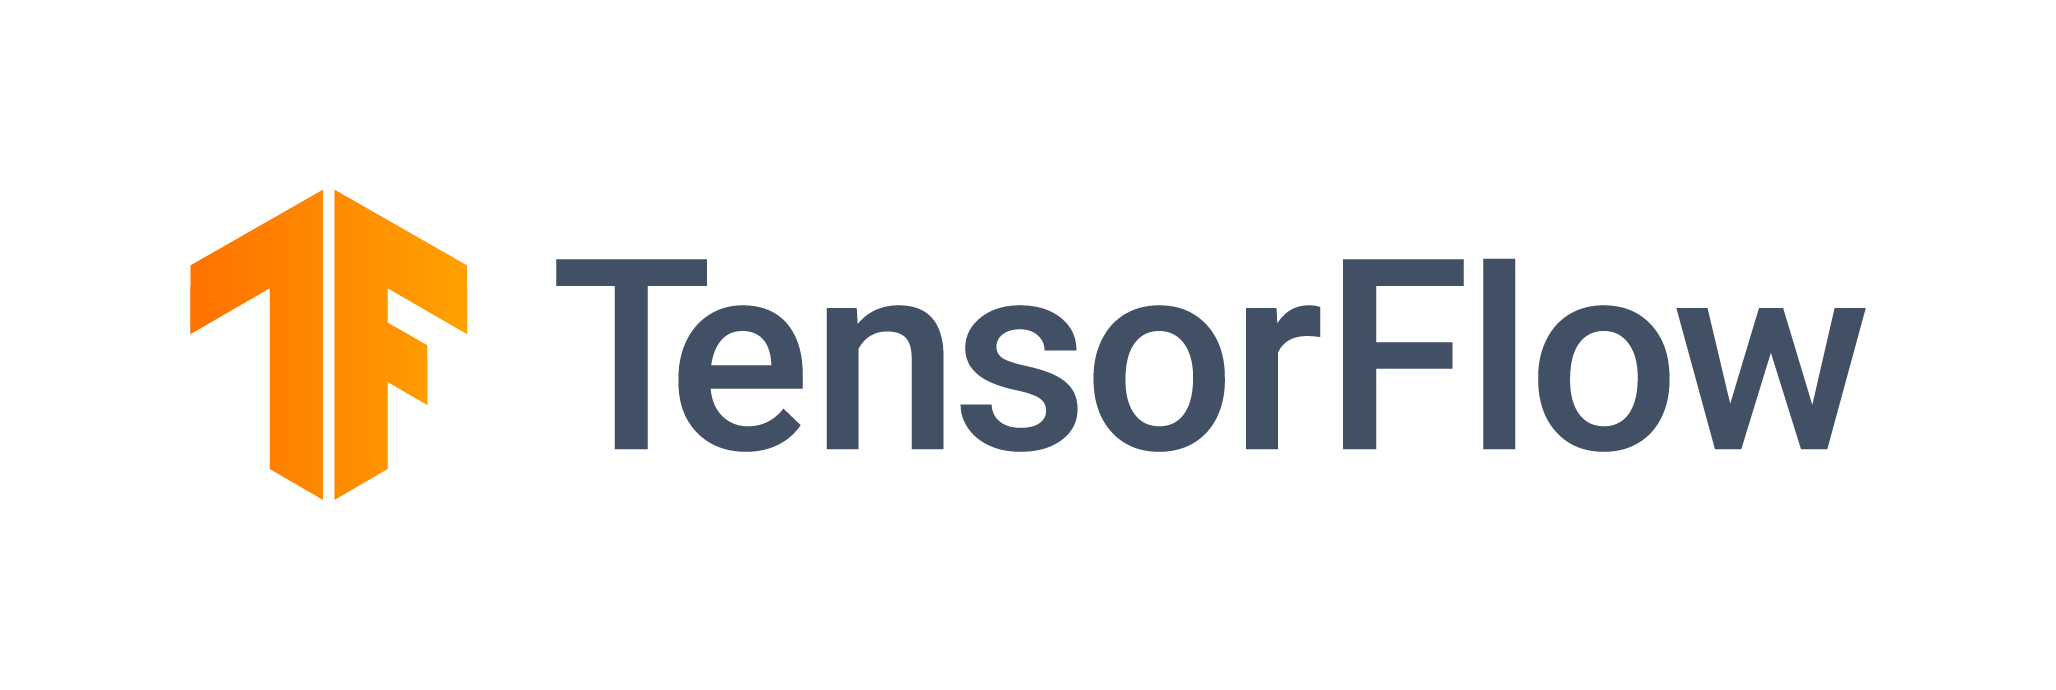

## - 구글에서 만든 머신러닝/딥러닝 프레임워크

## - 텐서플로우는 다양한 작업에 대해 데이터 흐름 프로그래밍을 위한 오픈소스 소프트웨어 라이브러리
## - 심볼릭 수학 라이브러리이자, 인공 신경망같은 기계 학습 응용프로그램 및 딥러닝에 사용

# Tensorflow를 이용한 wine 분류

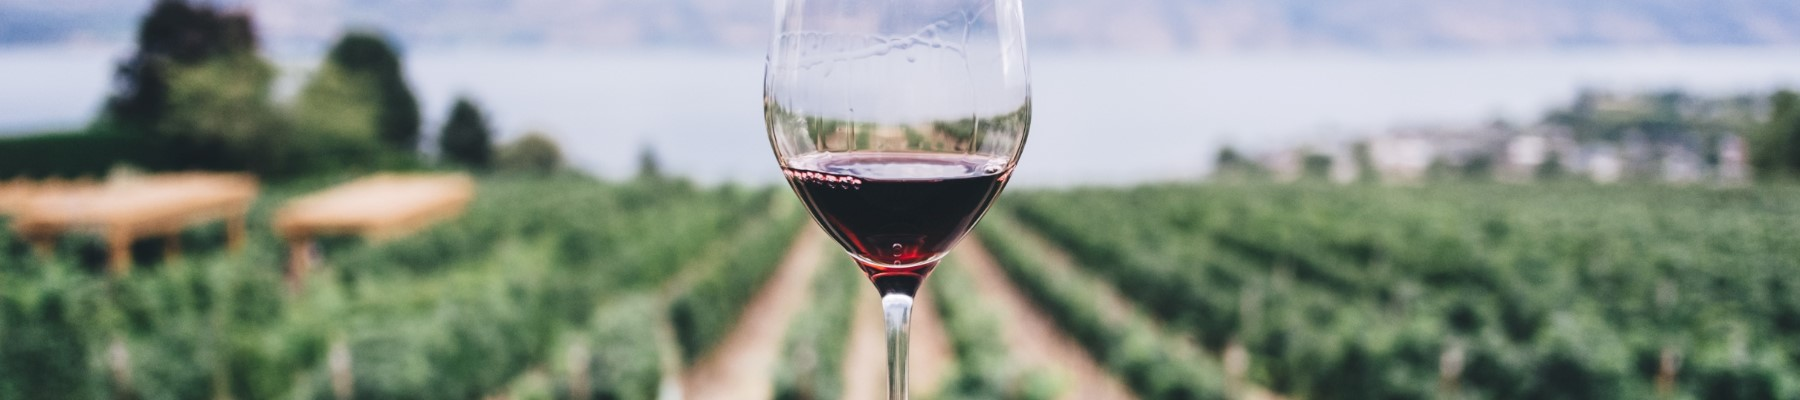

In [29]:
import numpy as np
import pandas as pd

## Wine Data 읽기

In [30]:
wine = pd.read_csv('https://raw.githubusercontent.com/wizard113/ML-Basic/main/wine.csv')

In [31]:
wine.head()

,alcohol,sugar,pH,class
0,9.4,1.9,3.51,0.0
1,9.8,2.6,3.20,0.0
2,9.8,2.3,3.26,0.0
3,9.8,1.9,3.16,0.0
4,9.4,1.9,3.51,0.0


In [32]:
wine.describe()

,alcohol,sugar,pH,class
count,6497.000000,6497.000000,6497.000000,6497.000000
mean,10.491801,5.443235,3.218501,0.753886
std,1.192712,4.757804,0.160787,0.430779
min,8.000000,0.600000,2.720000,0.000000
25%,9.500000,1.800000,3.110000,1.000000
50%,10.300000,3.000000,3.210000,1.000000
75%,11.300000,8.100000,3.320000,1.000000
max,14.900000,65.800000,4.010000,1.000000


In [33]:
np.unique(wine['class'], return_counts=True)

(array([0., 1.]), array([1599, 4898]))

## Data, Target 분리

In [34]:
wine.columns

Index(['alcohol', 'sugar', 'pH', 'class'], dtype='object')

In [35]:
input = wine[['alcohol', 'sugar', 'pH']].to_numpy()
target = wine['class'].to_numpy()

In [36]:
from sklearn.preprocessing import StandardScaler

In [37]:
ss = StandardScaler()
ss.fit(input)
input_scaled = ss.transform(input)

In [38]:
print(input_scaled[0])

[-0.91546416 -0.7447781   1.81308951]


## Train, Test 분리

In [39]:
from sklearn.model_selection import train_test_split

In [40]:
x_train, x_test, y_train, y_test = train_test_split(
    input_scaled, target, test_size=0.2, random_state=11
)

In [41]:
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(5197, 3) (5197,)
(1300, 3) (1300,)


## Model 생성

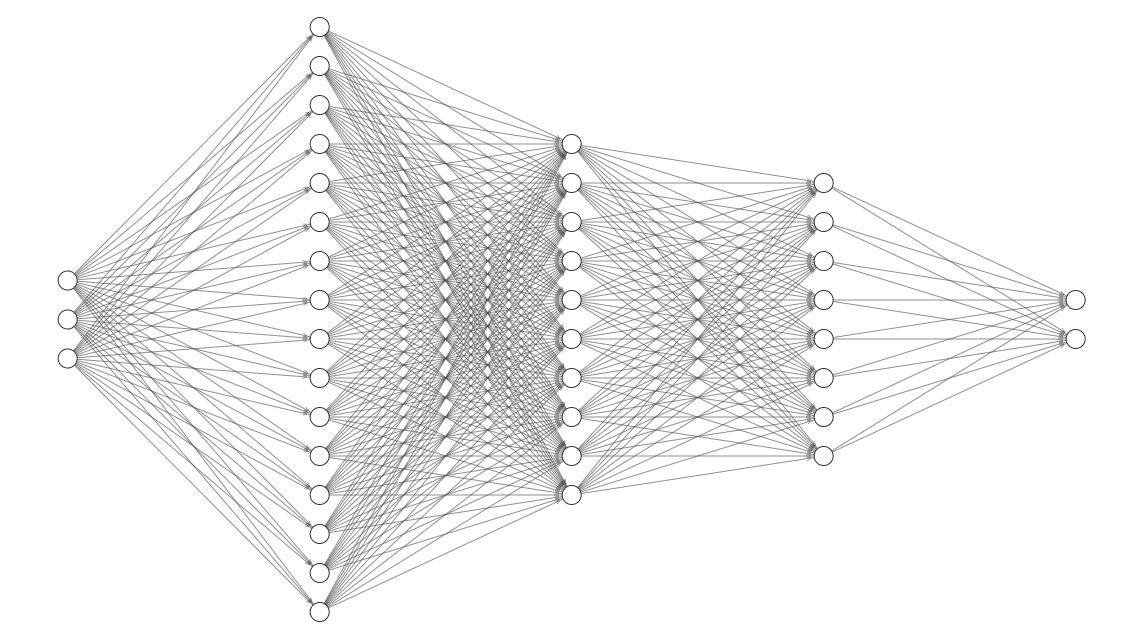

In [42]:
from tensorflow.keras import models, layers, utils

In [43]:
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(3,)))
model.add(layers.Dense(10, activation='relu'))
model.add(layers.Dense(8, activation='relu'))
model.add(layers.Dense(2, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [44]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           170 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │            88 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 340 (1.33 KB)

 Trainable params: 340 (1.33 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
print(y_train.shape, y_test.shape)

(5197,) (1300,)


In [46]:
y_train_oh = utils.to_categorical(y_train)
y_test_oh = utils.to_categorical(y_test)

In [47]:
print(y_train.shape, y_test_oh.shape)

(5197,) (1300, 2)


In [48]:
print(y_train_oh[50:100])

[[0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [0. 1.]
 [0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]
 [0. 1.]]


# 🔹 손실함수

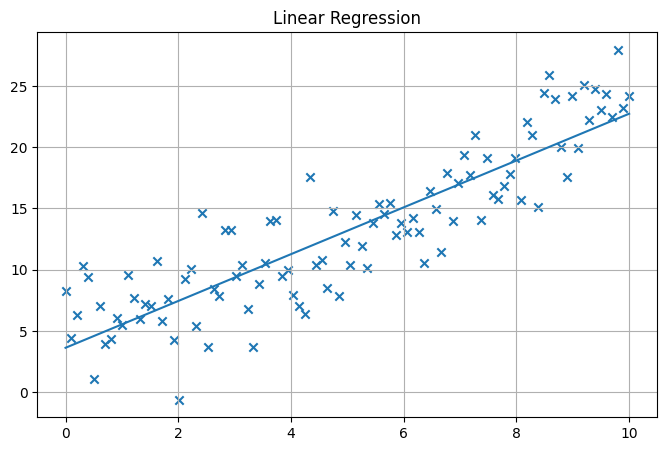

In [49]:
import matplotlib.pyplot as plt

# 랜덤 데이터 생성 (비슷한 느낌)
np.random.seed(0)
x = np.linspace(0, 10, 100)
y = 2 * x + 3 + np.random.randn(100) * 3

# 회귀선 (직선)
coef = np.polyfit(x, y, 1)   # 1차 회귀
y_pred = coef[0] * x + coef[1]

# 그래프
plt.figure(figsize=(8, 5))

# 산점도 (파란 X)
plt.scatter(x, y, marker='x')

# 회귀선 (빨간선)
plt.plot(x, y_pred)

plt.title("Linear Regression")
plt.grid()
plt.show()



## $$
\mathrm{MSE} = \frac{1}{N} \sum_{i=1}^{N} \left( y_i - \hat{y}_i \right)^2
$$

## 손실함수의 종류

### RMSE(Root Mean Squared Error)



MSE에 루트(√)를 씌운 것으로 MSE와 기본적으로 동일하다. MSE 값은 오류의 제곱을 구하기 때문에 실제 오류 평균보다 더 커지는 특성이 있어 MSE에 루트를 씌운 RMSE 은 값의 왜곡을 줄여준다.



### Binary Crossentropy


실제 레이블과 예측 레이블 간의 교차 엔트로피 손실을 계산한다. 레이블 클래스(0, 1로 가정)가 2개만 존재할 때 Binary Crossentropy를 사용하면 좋다.



### Categorical Crossentropy


다중 분류 손실함수로 출력값이 one-hot encoding 된 결과로 나오고 실측 결과와의 비교시에도 실측 결과는

one-hot encoding 형태로 구성된다.

예를 들면 출력 실측값이 아래와 같은 형태(one-hot encoding)로 만들어 줘야 하는 과정을 거쳐야 한다.
[[0 0 1]
 [0 1 0]
 [1 0 0]]  (배치 사이즈 3개인 경우)

네트웍 레이어 구성시 마지막에 Dense(3, activation='softmax') 로 3개의 클래스 각각 별로 positive 확률값이 나오게 된다.


[0.2, 0.3, 0.5]


위 네트웍 출력값과 실측값의 오차값을 계산한다.





### Sparse_Categorical_Crossentropy



'categorical_entropy'처럼 다중 분류 손실함수이지만, 샘플 값은 정수형 자료이다. 예를 들어, 샘플 값이 아래와 같은 형태일 수 있다. (배치 사이즈 3개)


[0, 1, 2]


네트웍 구성은 동일하게 Dense(3, activation='softmax')로 하고 출력값도 3개가 나오게 된다.

즉, 샘플 값을 입력하는 부분에서 별도 원핫 인코딩을 하지 않고 정수값 그대로 줄 수 있다. 이런 자료를 사용할 때, 컴파일 단계에서 손실 함수만  'sparse_categorical_crossentropy'로 바꿔주면 된다.



# 🔹 Optimizer (옵티마이저)

### Optimizer는 **손실 함수(Loss)를 최소화하기 위해 가중치(weight)를 업데이트하는 알고리즘**이다.

---

## 🔹 학습 흐름

###1. 입력 → 예측 수행  
###2. 손실(Loss) 계산  
###3. 기울기(Gradient) 계산  
###4. Optimizer가 가중치 업데이트  

---
## 🔹 기본 업데이트 공식

## $$
w = w - \eta \frac{\partial L}{\partial w}
$$

### ✔ 의미

### - $w$ : 가중치 (weight)  
### - $\eta$ : 학습률 (learning rate)  
### - $\frac{\partial L}{\partial w}$ : 손실 함수의 미분 (기울기)  

## 현재 값에서 **오차를 줄이는 방향(기울기의 반대 방향)**으로 이동

---

## 🔹 직관적 이해

### - 기울기 > 0 → 왼쪽 이동  
### - 기울기 < 0 → 오른쪽 이동  

## 항상 **손실이 줄어드는 방향으로 이동**

---
## 경사하강법
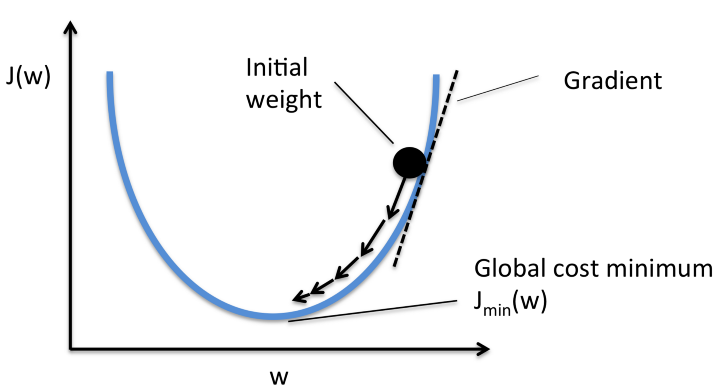

## 🔹 대표 Optimizer

### ✔ SGD (Stochastic Gradient Descent)
- 가장 기본적인 방식
- 단순하지만 느릴 수 있음

### ✔ Momentum
- 이전 방향을 기억 (관성)
- 더 빠르게 수렴

### ✔ Adam (가장 많이 사용)
- 학습률 자동 조정
- 빠르고 안정적
- 실무 기본값

---

In [50]:
model.compile(loss='mse',
              optimizer='sgd', metrics=['accuracy'])

In [51]:
model.fit(x_train, y_train_oh, epochs=200)

Epoch 1/200
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7445 - loss: 0.1910
Epoch 2/200
163/163 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7601 - loss: 0.1628
Epoch 3/200
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7601 - loss: 0.1567
Epoch 4/200
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7601 - loss: 0.1535
Epoch 5/200
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7601 - loss: 0.1510
Epoch 6/200
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7601 - loss: 0.1488
Epoch 7/200
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7601 - loss: 0.1468
Epoch 8/200
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7601 - loss: 0.1450
Epoch 9/200
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7601 - loss: 0.1434
Epoch 10/200
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7601 - loss: 0.1420
Epoch 11/200
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7601 - loss: 0.1407
Epoch 12/200
163/163 ━━━━━━━━━━━━━━━━━━━━

In [52]:
model.evaluate(x_test, y_test_oh)

41/41 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8577 - loss: 0.1090  


[0.10897628962993622, 0.857692301273346]

In [53]:
y_test[:10]

array([1., 1., 1., 0., 1., 1., 1., 1., 0., 0.])

In [54]:
pred = model.predict(x_test[:10])
print(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
[[1.7943841e-01 8.2056165e-01]
 [2.1435046e-01 7.8564954e-01]
 [2.0164801e-01 7.9835194e-01]
 [5.2878714e-01 4.7121289e-01]
 [3.0343553e-18 9.9999994e-01]
 [1.0914739e-01 8.9085251e-01]
 [3.5311490e-07 9.9999958e-01]
 [2.1000659e-01 7.8999341e-01]
 [6.9933611e-01 3.0066386e-01]
 [5.2382004e-01 4.7617996e-01]]


In [55]:
pred_index = np.argmax(pred, axis=1)
print(pred_index)

[1 1 1 0 1 1 1 1 0 0]


In [56]:
wine_type = ['white wine', 'red wine']
for p in pred_index:
  print(wine_type[p])

red wine
red wine
red wine
white wine
red wine
red wine
red wine
red wine
white wine
white wine
